The purpose of this notebook is to create the figures that are shown in the paper.  
 
To achieve this, we load the required data and libraries, and then program the figure visualizations

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.ticker import FuncFormatter
import geopandas as gpd
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, LogNorm, SymLogNorm
import scipy.io
from scipy.interpolate import griddata
import mat73
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import matplotlib as mpl
import seaborn as sns

/home/gloria_admin/anaconda3/envs/env/lib/python3.14/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

## **Five experiments**
The list with the five experiments were conducted in this paper: 
  
- ***proof***: The proof-of-concept experiment.  
  
- **_open_**: The proof-of-concept experiment using a broader initial parameter range.  
  
- **_exponential_ (expo)**: The exponential growth experiment, which removes the carrying capacity constraint.  
  
- **_no temperature dependance_ (temp)**:  The experiment that decouples speciation from temperature.  
   
- **_no food dependance_ (food)**: The experiment that removes the influence of marine export production on the speciation rate.

In [3]:
list_names=["proof","open","expo","temp","food"]

## **Five parameters**

The parameters used in the paper and its reference value:

- $K_{max}$: The upper boundary of the carrying capacity, with a reference value of 161.  
  
- $K_{min}$: The lower boundary of the carrying capacity, with a reference value of 19.  
  
- $\lambda_{max}$: The maximum potential speciation rate ($\lambda$), with a reference value of 0.035.  
  
- $\lambda_{max}$: The minimum potential speciation rate ($\lambda$), with a reference value of 0.002.  
   
- $Q_{10}$: The factor used to quantify the sensitivity of the speciation rate $\lambda$ to temperature, with reference value of 2.

In [4]:
variables = ['Kmax', 'Kmin','λmax', 'λmin','Q10']
mu=np.array([161, 19, 0.035, 0.002, 2])

#### Dictionary Section

The dictionary with the specific characteristics needed in the `generate_graphs` function for each one of the experiments:

- `name` (_str_): Name of the experiment (used to load the specific `.npz` file).
  
- `n_params` (_int_): Total number of parameters acroos each experiment.
  
- `n_range` (_tuple_): A tuple defining the start and end indices of parameters to iterate over using `range(*n_range)`.
  
- `rest_ax` (_int_): Offset index to align the data index with the subplot axes array.
  
- `omit_graph` (_int_ or _None_): The index of the axis to be removed if a blank subplot is present in the grid. If  `None`, no axis is deleted. 


In [5]:
experiments = {
    "proof": ["proof",5, (0,5), 0, 5],
    "open": ["open",5, (0,5), 0, 5],
    "expo": ["expo",3, (2,5), 2, 3, ],

    "temp": ["temp",4, (0,4), 0, None, (0.97, 0.9)],
    "food": ["food",5, (0,5), 0, 5],
}

In [6]:
#Set the font family to Arial
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

## **Figure Generation: Markov Chain Trajectories for Parameter Inference**

This section generates Figure 3 of the manuscript and the corresponding figures in the Annex. It plots the sampling history for the 5 parameters across the 5 different experiments: _proof_, _open_, _exponential_, _no temperature dependance_ and _no food dependance_.

#### **Plot details**

- **Trace Plots:** It shows the evolution of 5 model parameters ($K_{max}$, $K_{min}$, $\lambda_{max}$, $\lambda_{min}$ and $Q10$) over 5002 iterations for 6 independent MArkov chains.  

  
- **Reference Lines:**  
  
    - The **dashed red line** represents the trye value for each parameter.  
      
    - The **dashed blue line** indicates the mean value of the posterior distribution after the burn-in period.  
      
- **Outputs:** Figures are automatically saved in high-resolution PDF format inside the _/chains_ directory   

#### **Function Arguments (`generate graphs`)**  
  
To accomodate the specific layout needs of different experiments (e.g., when some subplots need to be omitted due to different parameter counts), the function accepts the parameters explained before.  They are saved in the dictionary with a list for each parameter.


In [7]:
def generate_graphs(name, n_params, n_range, rest_ax, omit_graph, pos_legend=(0.97,0.05)):
    
    #Load the data for the accepted parameters of each experiment
    data_output=np.load(f"output_data/inditekMCMCoutput_5002_{name}.npz")
    params_accepted_history=data_output["params_accepted_history"]

    #Select chains with good behavior for further analysis (correspond to the 3d column)
    if name=="temp":
        well_accepted_history=params_accepted_history[2000:,:,1:5] #after the 2000 iteration (burn-in)
    elif name=="expo":
        well_accepted_history=params_accepted_history[2000:,:,[0,1,2,4,5]]
    else:
        well_accepted_history=params_accepted_history[2000:,:,:]
    
    A=[]
    #Calculate the mean of the accepted parameters
    for j in range(5):
        A.append(np.mean(well_accepted_history[:,j]))

    #Create the figure with the corresponding subplots
    fig, axs = plt.subplots((n_params+1) //2, 2, figsize=(10, 6), sharex=False, sharey=False)

    # Flatten the array to simplify further processing
    axs = axs.flatten()

    ax_blank = fig.add_axes([0.15, 0.9, 0.5, 0.15])  # [left, bottom, width, height]
    ax_blank.axis('off')

    #Loop through each parameter and chain
    #to plot all chains across all parameters
    for j in range(*n_range):#Parameter index
        ax = axs[j-rest_ax]
        for i in range(6):#Chain index
            #We plot the chains
            ax.plot(np.arange(0, params_accepted_history.shape[0]), params_accepted_history[:, j, i], label=f'chain {i}')
        ax.set_title(variables[j], fontsize=18)
        
        #The horizontal dashed red line representing the reference value
        ax.axhline(y=mu[j], color='red', linestyle='--', linewidth=1, label='Reference \n value')
        #The horizontal dashed blue line with the average value
        ax.axhline(y=A[j], color='blue', linestyle='--', linewidth=1, label='Mean value')
        
        #Add the horizontal and the vertical axis labels
        ax.set_xlabel('Iteration', fontsize=12)
        ax.set_ylabel('Parameter value', fontsize=12)

        #Set the horizontal and vertical limits for the figure
        ax.set_xlim(0, params_accepted_history.shape[0])
        y_min=0.8*np.min(params_accepted_history[:, j, :])
        y_max=1.05*np.max(params_accepted_history[:, j, :])
        ax.set_ylim(y_min, y_max)


    #Place the label in the correct position
    handles, labels = axs[0].get_legend_handles_labels()

    fig.legend(handles, labels, loc='lower right', fontsize=13, bbox_to_anchor=pos_legend)  # Ajusta la posición según sea necesario


    #Place the letters in the correct position
    letras = ['a', 'b', 'c', 'd', 'e', 'f']

    for i in range(*n_range):
        texto = f"({letras[i-rest_ax]})"
        axs[i-rest_ax].text(-0.01, 1.05, texto, transform=axs[i-rest_ax].transAxes, 
            fontsize=16,  va='bottom', ha='right')
    
    #Hide the unused subplot where no parameter data is present
    if omit_graph is not None:
        fig.delaxes(axs[omit_graph])

    #Add padding around the borders to prevent clipping
    plt.tight_layout(rect=[0, 0, 1.1, 1.4])  
    
    #Save the figure to a file and display it on screen
    plt.savefig(f"images/Chains_{name}_5002.png", bbox_inches='tight')
    plt.show()

    #Return the average value for each parameter
    return A

/tmp/ipykernel_107915/197170439.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1.1, 1.4])


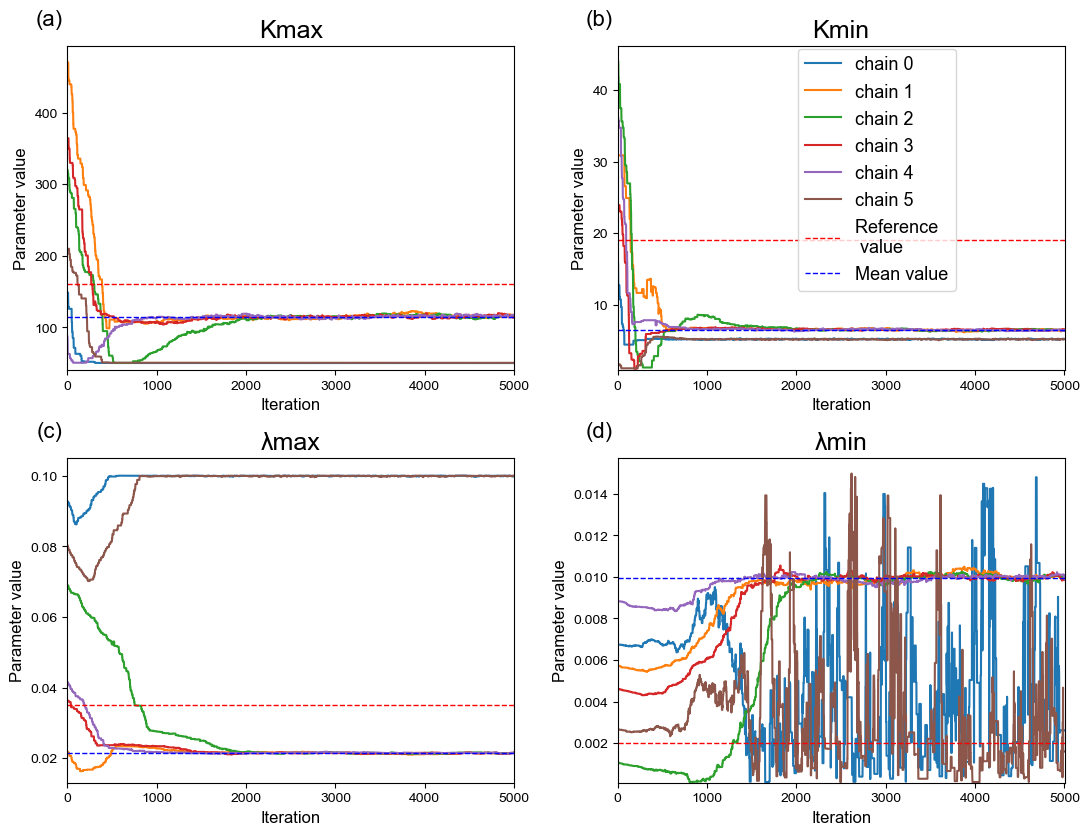

115.06628687510656
6.46165828011009
0.021471679937540702
0.009954465654992329
nan


In [8]:
#Select the specific experiment to plot
list_exp=experiments.get("temp")
A=generate_graphs(*list_exp)

#Print the average value for each parameter
for i in range(len(A)):
    print(A[i])

## **Figure Generation: Validation of the INDITEK-2.0'S Bayesian inverse modelling framework**

This section generates **Figure 3** of the manuscript and the corresponding figures in the **Appendix**. In the diagonal panels, it plots the one-dimensional posterior distribution for the 5 parameters across the 5 different experiments. In the upper triangle, it shows the joint posterior distributions and correlations between parameter pairs for the 5 parameter combinations across the 5 different experiments.

**Plot Details for the Diagonal Panels**  
  
- **Histogram Bars:** Represent the frequency of each value for 5 model parameters () calculated after a burn-in period of 2000 iterations.  
- **Reference lines:**
    - The **dashed red line** represents the true reference value for each parameter.
    - The **dashed blue line** represents the mean value of the posterior distribution calculated after a burn-in period of 2000 iterations.

**Plot details for the upper triangle**

- **Color Scale** The color of each square (bin) represents the frequency of the joint posterior distribution for parameters pairs, calculated after the burn-in period.  
- **Yellow square:** Highlights the specific bin containing the true reference value for each combination of parameters.

#### **Function arguments (`generate_histo`)**

To accomodate the specific layout needs of differents experiments (e.g. adjusting the number of plots in the diagonal depending on the number of active parameters), the function uses the same parameters described in the previous section's dictionary:
- `name`: Name of the experiment
- `n_params`: Total number of parameters.
- `n_range`: Tuple definig the parameter indices
- `rest_ax`: Offset index for axes alignment

In [9]:
range_ticks=[[155,170],[18,19.5],[0.0342,0.0355],[0.0016,0.0026],[1.925,2.075]]

In [10]:
from matplotlib import ticker


def generate_histo(name, n_params, n_range, rest_ax):

    #Load the data for the accepted parameters of each experiment
    data_params=np.load(f"output_data/inditekMCMCoutput_5002_{name}.npz")
    params_accepted_history=data_params["params_accepted_history"]

    # Sample data
    
    global_min = np.inf
    global_max = -np.inf

    #Define the colormap
    cmap = LinearSegmentedColormap.from_list("white_blue", ["white", "blue",  "red"])
    
    #Create the figure with the corresponding subplots
    fig, axs = plt.subplots(n_params, n_params, figsize=(18, 14), sharex=False, sharey=False)
    
    #Nested loop through parameters to plot 1D posterior histograms and 2D joint posterior distributions
    for i in range(*n_range):
    
        for j in range(*n_range):
            
            #The one-dimensional posterior distributions is plotted here
            if i==j:
                #Calculate and print the 95% confidence interval
                ci_lower = np.percentile(params_accepted_history[2000:, j].ravel().astype(float), 2.5)
                ci_upper = np.percentile(params_accepted_history[2000:, j].ravel().astype(float), 97.5)
                print(f"{variables[j]}: 95% CI = [{ci_lower:.4f}, {ci_upper:.4f}]")

                #Select the diagonal panels for the 1D histograms
                ax = axs[i-rest_ax,j - rest_ax]
                #The horizontal dashed red line with the reference value
                line = ax.axvline(x=mu[j], color='red', linestyle='--', linewidth=2, label='Reference value')
                #The horizontal dashed blue line with the average value
                line2 = ax.axvline(x=np.mean(params_accepted_history[2000:,j]), color='darkblue', linestyle='--', linewidth=2, label='Mean value')

                # Calculate the histograms using 20 bars
                data_params = params_accepted_history[2000:, j].ravel().astype(float)
                counts, bins = np.histogram(data_params, bins=20, density=False)

                #Normalize tje counts by the total sum to calculate the probability of each value
                probs=counts/counts.sum()
    
                #Plot the histogram
                ax.bar((bins[:-1] + bins[1:]) / 2, probs, 
                width=np.diff(bins), align="center", edgecolor='black', color='lightgray')

                #Add the horizontal and vertical axis labels
                ax.set_title(variables[j], fontsize=20, y=-0.4)
                ax.set_ylabel(f'{variables[i]} \n Probability', fontsize=20)
                #Set the horizontal and vertical axis limits for the figure
                ax.set_xlim(range_ticks[i][0], range_ticks[i][1])
                ax.set_ylim(0,0.3)

                #Set the axis ticks marks and labels 
                ax.set_xticks(np.round(np.linspace(range_ticks[i][0], range_ticks[i][1], 4), 4))
                ax.set_yticks([0,0.1,0.2,0.3])
                ax.set_yticklabels(['0', '0.1', '0.2', '0.3'])
                
                #Format smalls values in scientific notation for better readability
                formatter = ticker.ScalarFormatter(useMathText=True) #Apply scientific notation to the axis formatting
                formatter.set_scientific(True)
                if j==2:
                    formatter.set_powerlimits((-2, -2)) 
                    ax.xaxis.set_major_formatter(formatter)
                elif j==3:
                    formatter.set_powerlimits((-3, -3)) 
                    ax.xaxis.set_major_formatter(formatter)
            
            #Plot the joint posterior distributions
            elif j>i:
                #Select the upper-diagonal panels
                ax = axs[i-rest_ax, j - rest_ax]
                #Flatten the data to create the histograms
                x = params_accepted_history[2000:, j, :].ravel()
                y = params_accepted_history[2000:, i, :].ravel()
                
                #This draws a normalized 2d-histogram, where the total sum is equal to 1.
                weights = np.ones_like(x) / len(x)
                hist = ax.hist2d(x, y, weights=weights, cmap=cmap)
    
    
                # Compute and plot a normalized 2D histogram where the total sum equals 1
                fixed_value_x=mu[j]
                fixed_value_y=mu[i]

                #Extract the results from the histogram
                im=hist[3]#the image object for the colorbar
                x_edges= hist[1]
                y_edges= hist[2]
    
                #Locate the cell containing mu (the reference value)
                x_bin = np.digitize(fixed_value_x, x_edges) - 1#Column index
                y_bin = np.digitize(fixed_value_y, y_edges) - 1#Row index
    
                x_start = x_edges[x_bin]#Left border of that cell
                y_start = y_edges[y_bin]#Inferior border of that cell
                bin_width = x_edges[1] - x_edges[0]#Widht of the cell
                bin_height = y_edges[1] - y_edges[0]#Height of the cell
    
                # Draw the yellow rectangle in that position
                rect = Rectangle((x_start, y_start), bin_width, bin_height,
                                 edgecolor='yellow', facecolor='none', linewidth=3, label='Reference value')
                ax.add_patch(rect)

                #Set the borders and the tick marks for the x and y axes
                ax.set_xticks(np.round(np.linspace(range_ticks[j][0], range_ticks[j][1], 4), 4))
                ax.set_xlim(range_ticks[j][0], range_ticks[j][1])
                ax.set_yticks(np.round(np.linspace(range_ticks[i][0], range_ticks[i][1], 4), 4))
                ax.set_ylim(range_ticks[i][0], range_ticks[i][1])

                #Format small values in scientific notation for better readability
                formatter = ticker.ScalarFormatter(useMathText=True) # Use scientific notation
                formatter.set_scientific(True)
                if i==2:
                    formatter.set_powerlimits((-2, -2)) 
                    ax.yaxis.set_major_formatter(formatter)
                    if j==3:
                        formatter.set_powerlimits((-3, -3)) 
                        ax.xaxis.set_major_formatter(formatter)
                elif j==2:
                    formatter.set_powerlimits((-2, -2)) 
                    ax.xaxis.set_major_formatter(formatter)
                elif j==3:
                    formatter.set_powerlimits((-3, -3))
                    ax.xaxis.set_major_formatter(formatter)
                
                elif i==3:
                    formatter.set_powerlimits((-3, -3))
                    ax.yaxis.set_major_formatter(formatter)
                else:
                    formatter.set_scientific(False)
                    
                
               
            #Hide the unused subplot where no histograms are represented
            else:
                fig.delaxes(axs[i - rest_ax,j - rest_ax])
                
    
    #Represent the colorbar for the joint posterior distributions and sets the tick marks
    
    cbar = fig.colorbar(im, ax=axs, orientation='horizontal', fraction=0.02, pad=0.02)
    cbar.set_label("Frequency of each combination", fontsize=12)

    cbar.mappable.set_clim(0, 0.1)
    cbar.set_ticks(np.linspace(0, 0.1, 5))
    cbar.set_ticklabels(['0', '0.025', '0.05', '0.075', '0.1'])

    #Set the labels for all plots in their correct positions
    handles1, labels1 = axs[0,0].get_legend_handles_labels()
    handles2, labels2 = axs[0,1].get_legend_handles_labels()
    handles = handles1 + handles2
    labels = labels1 + labels2
    
    fig.legend(handles, labels, loc='lower left', fontsize=15, bbox_to_anchor=(0.45, 0.2))
    
    #Create a white border around the figure
    plt.tight_layout(rect=[0, 0, 1, 0.95])  

    #Save the figure to a file and display it on screen
    plt.savefig(f"images/histogram2D_{name}.png")
    plt.show()
    

Kmax: 95% CI = [157.6069, 167.3590]
Kmin: 95% CI = [18.3885, 19.1875]
λmax: 95% CI = [0.0345, 0.0352]
λmin: 95% CI = [0.0018, 0.0024]
Q10: 95% CI = [1.9552, 2.0497]


/tmp/ipykernel_107915/1874074933.py:162: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


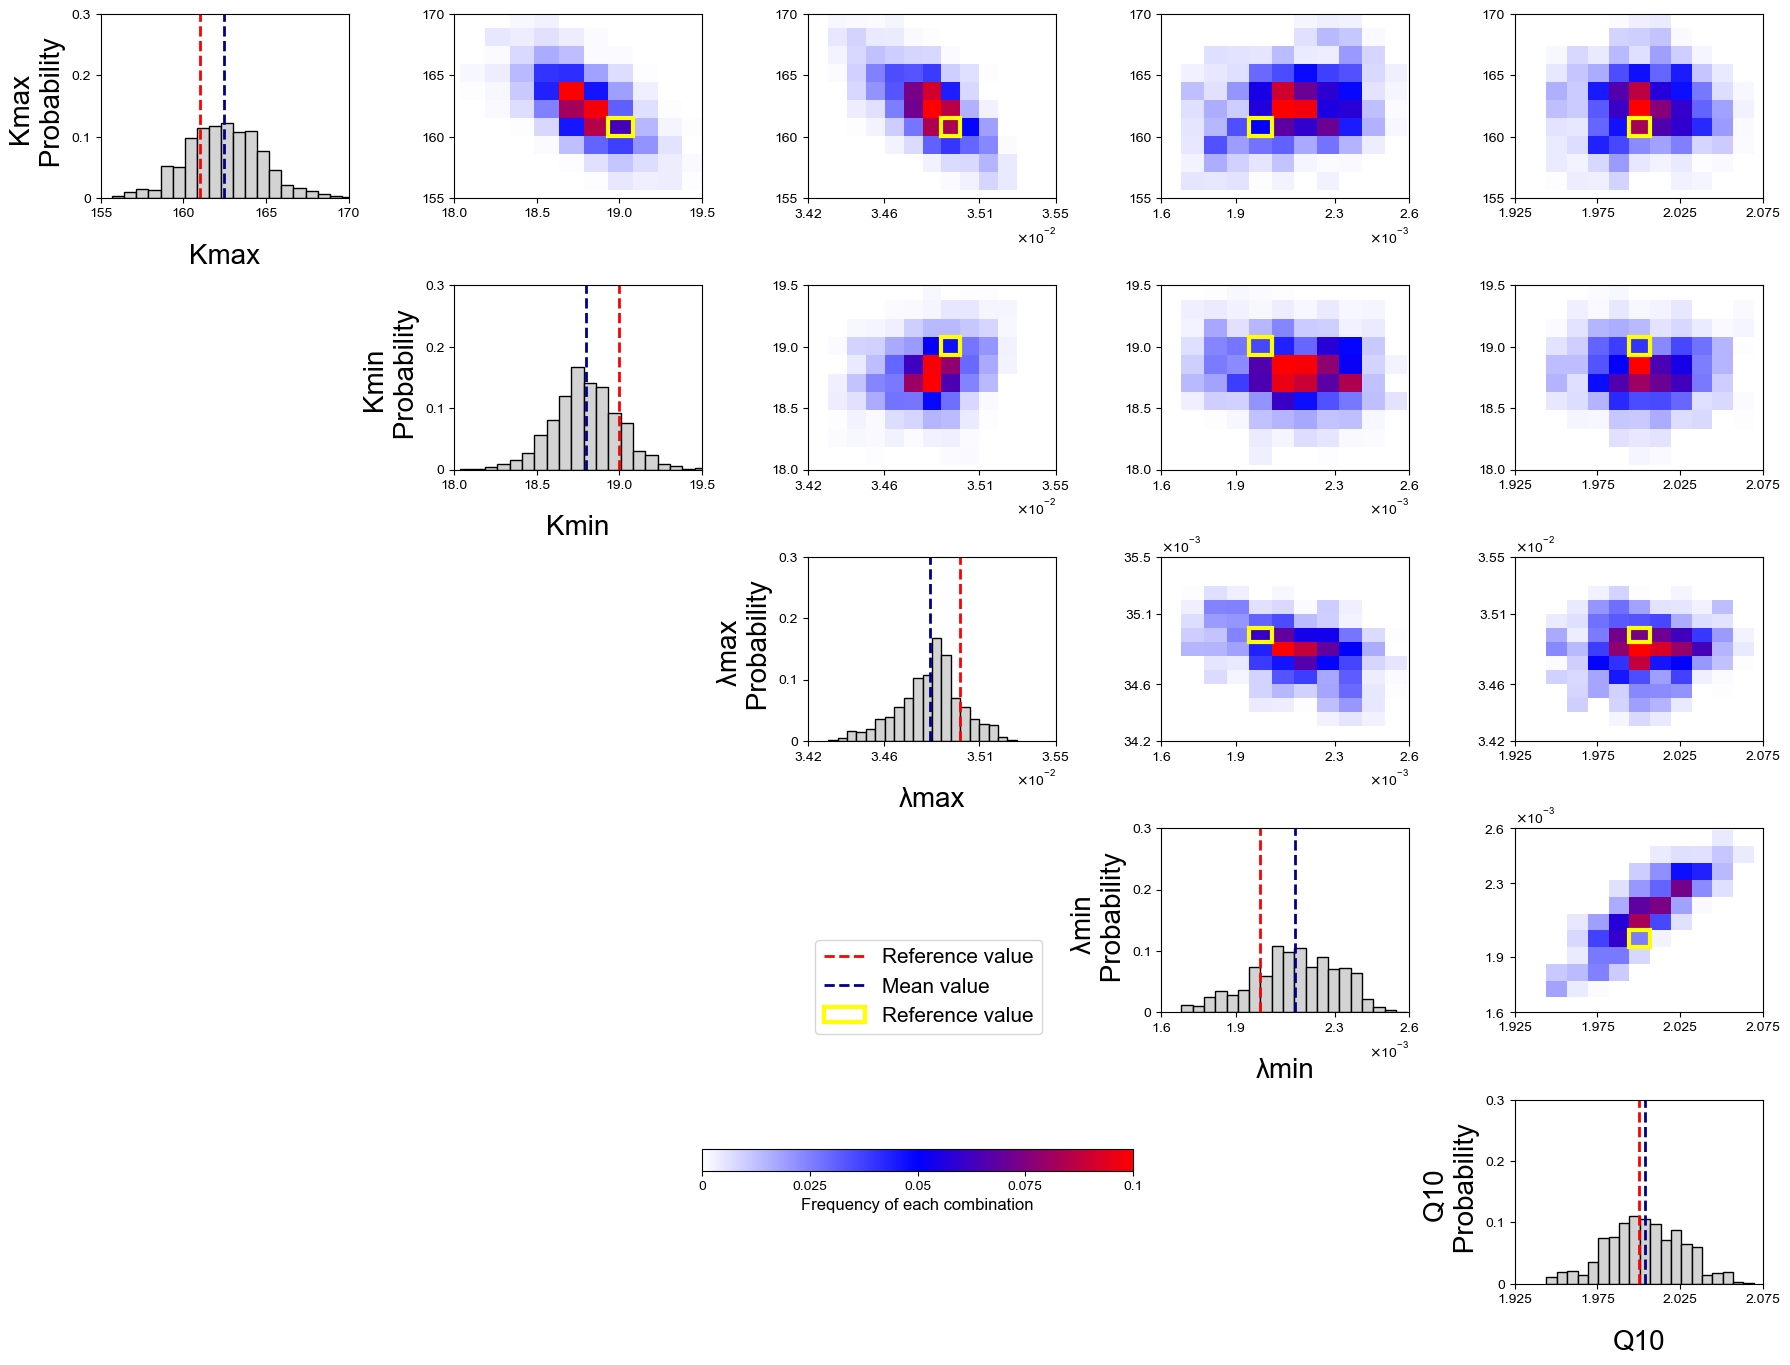

In [11]:
#Select the specific experiment to plot
list_exp=experiments.get("proof")
generate_histo(list_exp[0],list_exp[1],list_exp[2],list_exp[3])

## **Figure Generation: Parameter posterior distributions and residual sum of squares across model configurations**

This section generates **Figure 4** of the manuscript. For the five first panels, from (A) to (E), it plots the one-dimensional posterior distribution for the five different exoeriments: _proof_, _open_, _exponential_, _no temperature dependance_ and _no food dependance_. For the panel (F), it plots the residual sum of squares acroos the 5 different experiments: : _proof_, _open_, _exponential_, _no temperature dependance_ and _no food dependance_.

#### **Plot details for panels (a) to (e)**

- **Kernel Plots**: Represent the frequency of each value for five model parameters calculated after a burn-in period of 2000 iterations.

#### **Plot details for panel (f)**

- **Trace Plots:** It shows the evolution of the RSS over 5002 iterations for the five different experiments.  
  
- **Outputs:** The figures is automatically saved in high-resolution PDF format in the root `chains/residual_errors`.

In [12]:
#Load the accepted parameter values of each experiment
#Proof-of-concept
data_proof=np.load(f"output_data/inditekMCMCoutput_5002_proof.npz")
params_accepted_proof=data_proof["params_accepted_history"]
#Experiment 1 (open)
data_open=np.load(f"output_data/inditekMCMCoutput_5002_open.npz")
params_accepted_open=data_open["params_accepted_history"]
#Experiment 2 (exponential)
data_expo=np.load(f"output_data/inditekMCMCoutput_5002_expo.npz")
params_accepted_expo=data_expo["params_accepted_history"]
#Experiment 3 (temperature)
data_temp=np.load(f"output_data/inditekMCMCoutput_5002_temp.npz")
params_accepted_temp=data_temp["params_accepted_history"]
#Experiment 4 (food)
data_food=np.load(f"output_data/inditekMCMCoutput_5002_food.npz")
params_accepted_food=data_food["params_accepted_history"]

In [13]:
#Select only the chains with normal behavior from the temperature and exponential experiments for further analysis
params_accepted_temp=params_accepted_temp[:,:,1:5]
params_accepted_expo=params_accepted_expo[:,:,[0,1,2,4,5]]

The functions for the y-axis scale in the (F) panel. It increases in a logarithmic scale until a reference point, called `punto_corte`, then the scale is reducing following a reducing factor called `factor_compresion`

In [14]:

def forward(y,  cut_point, compress_factor):
    """Map the real values to their corresponding position in the graph"""
    y = np.maximum(y, 1e-10) # Avoid mistakes if there is any zero
    ly = np.log10(y)
    # If the value is less than 10^8, keep it as normal; if greater, compress it
    return np.where(ly <= cut_point, ly, cut_point + (ly - cut_point) * compress_factor)

def inverse(y_prime, cut_point, compress_factor):
    """Convert back to the original format (required for Matplotlib)"""
    ly = np.where(y_prime <= cut_point, y_prime, cut_point + (y_prime - cut_point) / compress_factor)
    return 10**ly

def log_format(x, pos):
    if x > 0:
        return f'$10^{{{int(np.log10(x))}}}$'
    return ''

In [15]:
color_name=["purple", "green", "red", "darkorange", "dodgerblue"]

For the experiment Proof of Concept, the reference RSS is: 2730.189034293991
For the experiment Experiment 1 (open), the reference RSS is: 3326.0195061325007
For the experiment Experiment 2 (exponential), the reference RSS is: 11515.36676848568
For the experiment Experiment 3 (food), the reference RSS is: 45111.70213998504
For the experiment Experiment 4 (temperature), the reference RSS is: 4631.507648445689


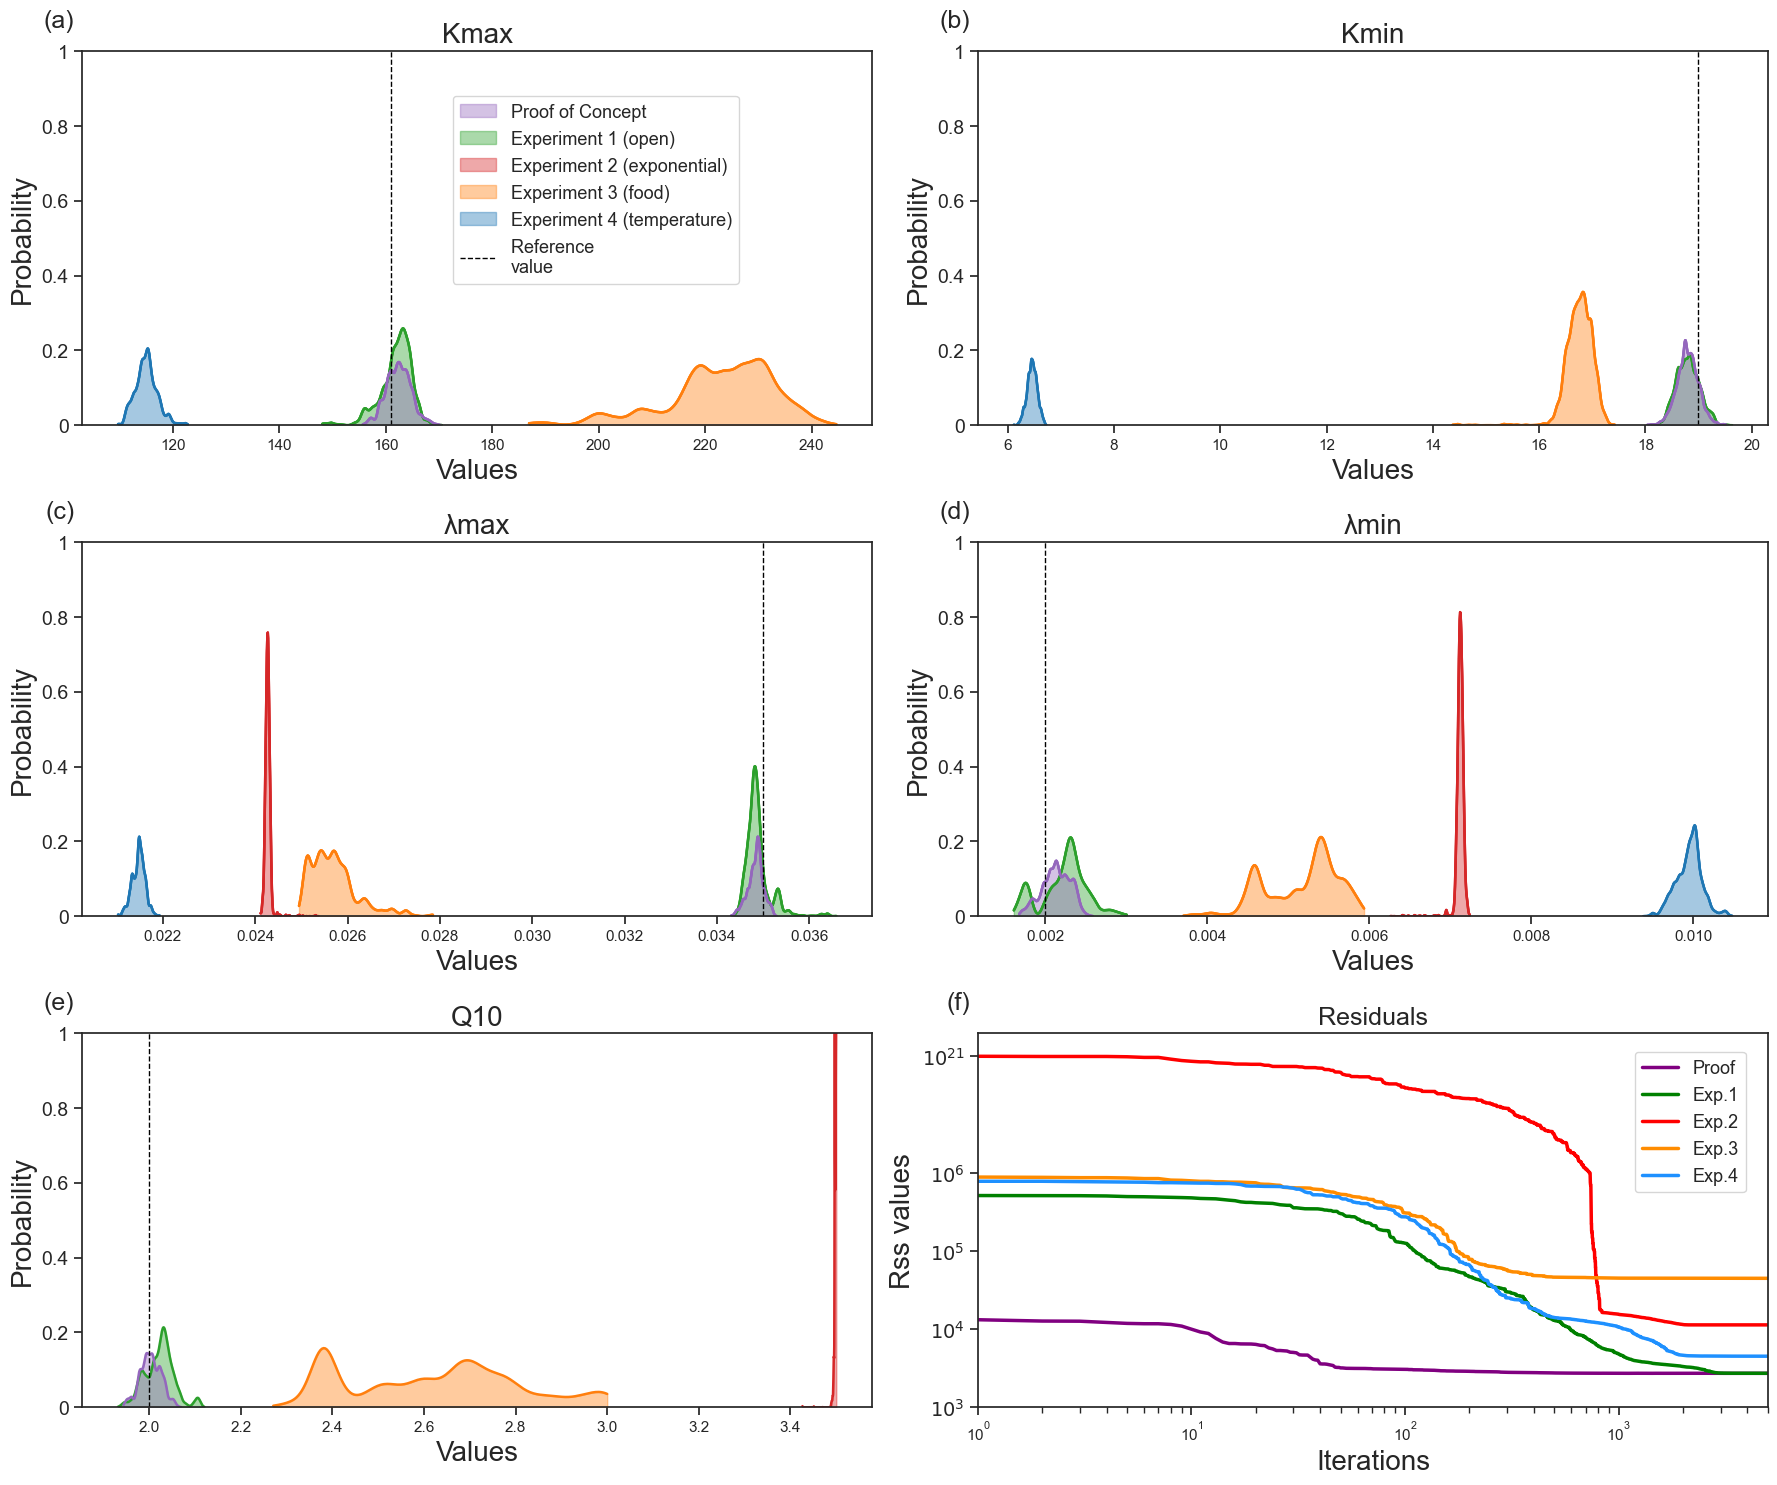

In [16]:
# 1. Create the figure with the corresponding subplots and configure the visual style (without grid)
sns.set_theme(style="ticks")
fig, axs = plt.subplots(3, 2, figsize=(18, 15))

axs = axs.flatten()

for i in range(5):

    # 2. Store the data in a dictionary for later retrieval
    datos = {
        "Experiment 4 (temperature)": params_accepted_temp[2000:, i].ravel().astype(float),
        "Experiment 3 (food)": params_accepted_food[2000:, i].ravel().astype(float),
        "Experiment 1 (open)": params_accepted_open[3000:, i].ravel().astype(float),
        
        
        "Experiment 2 (exponential)": params_accepted_expo[2000:, i].ravel().astype(float),
        "Proof of Concept": params_accepted_proof[2000:, i].ravel().astype(float)
    }

    # 3. Create the colorset (one for each experiment)
    color_name=["purple", "green", "red", "darkorange", "dodgerblue"]
    colores = sns.color_palette("tab10", len(datos))
    
    # 4. Plot the overlapping histograms with a Kernel Density Estimator (KDE) curve
    for (nombre, valores), color in zip(datos.items(), colores):
        valores_limpios = valores[~np.isnan(valores)]
        
        if len(valores_limpios) > 0:

            # Create the KDE curves
            sns.histplot(
                valores_limpios,
                bins=15,
                color=color,
                kde=True,
                alpha=0,
                linewidth=0,
                stat="probability",
                ax=axs[i]
            )


            # 2. Fill the area under the curves
            kde_line = axs[i].lines[-1]
            x_kde = kde_line.get_xdata()    
            y_kde = np.clip(kde_line.get_ydata(),0 ,1)
            if i==4:
                kde_line.set_visible(False)
            else:
                axs[i].plot(x_kde, y_kde, color=color, linewidth=1.8)
            axs[i].fill_between(
                x_kde, y_kde,
                alpha=0.4,
                color=color,
                label=nombre       # Set the label for the legend
            )
            
            axs[i].plot(x_kde, y_kde, color=color, linewidth=1.8)

            kde_line.set_label("_nolegend_")  # Prevent duplicates labels in the legend
    
    #The vertical dashed line with the reference value
    axs[i].axvline(x=mu[i], color='black', linestyle='--', linewidth=1, label='Reference \nvalue')

    #Set the x and y labels and the title using the parameter name
    axs[i].set_xlabel("Values", fontsize=20)
    axs[i].set_ylabel("Probability", fontsize=20)
    axs[i].set_title(variables[i], fontsize=20)

    #Set the ticks and the limits for the vertical axis
    axs[i].set_yticks([0,0.2,0.4,0.6,0.8,1])
    axs[i].set_yticklabels(['0', '0.2', '0.4', '0.6', '0.8', '1'], fontsize=14)
    axs[i].set_ylim(0,1)

#Plot the labels for the first diagrams in their correct position
handles, labels = axs[2].get_legend_handles_labels()
orden_deseado= ["Proof of Concept", "Experiment 1 (open)", "Experiment 2 (exponential)", "Experiment 3 (food)", "Experiment 4 (temperature)", "Reference \nvalue"]
orden = [labels.index(name) for name in orden_deseado]

# Plot the legend in the correct position
handles = [handles[k] for k in orden]
labels  = [labels[k]  for k in orden]
fig.legend(handles, labels, loc='lower right', fontsize=13, bbox_to_anchor=(0.42, 0.8))


tick_legend=['Proof', 'Exp.1', 'Exp.2', 'Exp.3', 'Exp.4']

#Plot panel (f) showing the RSS values across the 5002 iterations
for i, name in enumerate(list_names):
    #Load the data containing the RSS accepted values
    data_output=np.load(f"output_data/inditekMCMCoutput_5002_{name}.npz")
    rss_accepted=data_output["rss_accepted_history"]
    #Average across chains to get a single value per iteration
    rss=np.mean(rss_accepted, axis=1)
    rssref=np.mean(rss_accepted[2000,:])
    axs[5].plot(np.arange(1,rss_accepted.shape[0]), rss[1:], label=tick_legend[i], color=color_name[i], linewidth=2.5)
    print(f"For the experiment {orden_deseado[i]}, the reference RSS is: {rssref}")

#Compress data above 10⁶ and plot it on a logarithmic scale
cut_point=6
compress_factor = 0.1

axs[5].set_yscale('function', functions=(
    lambda y: forward(y, cut_point, compress_factor), 
    lambda y_prime: inverse(y_prime, cut_point, compress_factor)
))
axs[5].yaxis.set_major_formatter(FuncFormatter(log_format))

#Set the x-axis to a logarithmic scale and set the limits for both axes
axs[5].set_xscale('log')
axs[5].set_ybound(1e3,1e24)
axs[5].set_xbound(1,rss_accepted.shape[0])

#Set the x and y labels and the title
axs[5].set_xlabel("Iterations", fontsize=20)
axs[5].set_ylabel("Rss values", fontsize=20)
axs[5].set_title("Residuals", fontsize=18)

#Set the ticks in the correct position
ticks = [1e3,1e4, 1e5, 1e6, 1e21]
axs[5].set_yticks(ticks)
axs[5].tick_params(axis='y', labelsize=14)


#Plot the legend

axs[5].legend(fontsize=13, bbox_to_anchor=(0.82, 0.55))

#Position the panel letters correctly on each plot 
letras = ['a', 'b', 'c', 'd', 'e', 'f']

for i in range(6):
    texto = f"({letras[i]})"
    axs[i].text(-0.01, 1.05, texto, transform=axs[i].transAxes, 
            fontsize=18,  va='bottom', ha='right')
plt.tight_layout()

#Save the figure to a file and display it on screen
plt.savefig(f"images/histo_log_scale.png")
plt.show()

## **Figure Generation: Observed versus estimated diversity maps**

This section generates the diversity maps from **Figure 1** of the manuscript. It consists on two panels: the first represents the biodiversity map simulated with the reference parameter, the one used as the observed reference during the comparisons. The second panel displays the estimated diversity map obtained by using the average values of the five model parameters calculated after the burn-in period.

#### **Plot details for both maps**

- **Spatial scale and Resolution:** Both panels render global diversity maps mapping the geographic distribution of species richness.
- **Color Scale:** The diversity in both maps is represented following a $log_2$ scale to highlight variations across regions with high and low species diversity.
- **Outputs:** The figure is automatically saved in high-resolution SVG format in the root directory `maps/map_observed_proof.svg`

In [17]:
#Load the diversity data for both maps
data_proof=np.load("data/observed_D.npz")
proof=data_proof["proof"]
data_mean=np.load("tool_for_images/D_mean.npz")
D_mean=data_mean["D"]

#Load the mask data to plot the diversity values
data_mask=mat73.loadmat('data/landShelfOceanMask.mat')
landShelfOcean_Lat=data_mask['landShelfOcean_Lat']
landShelfOcean_Lon=data_mask['landShelfOcean_Lon']
landShelfOceanMask=data_mask['landShelfOceanMask']

#Transpose the mask to align it to a North-South orientation
landShelfOceanMask = np.flip(landShelfOceanMask, axis=2)
LSOmask=np.transpose(landShelfOceanMask[:,:,landShelfOceanMask.shape[2]-1])

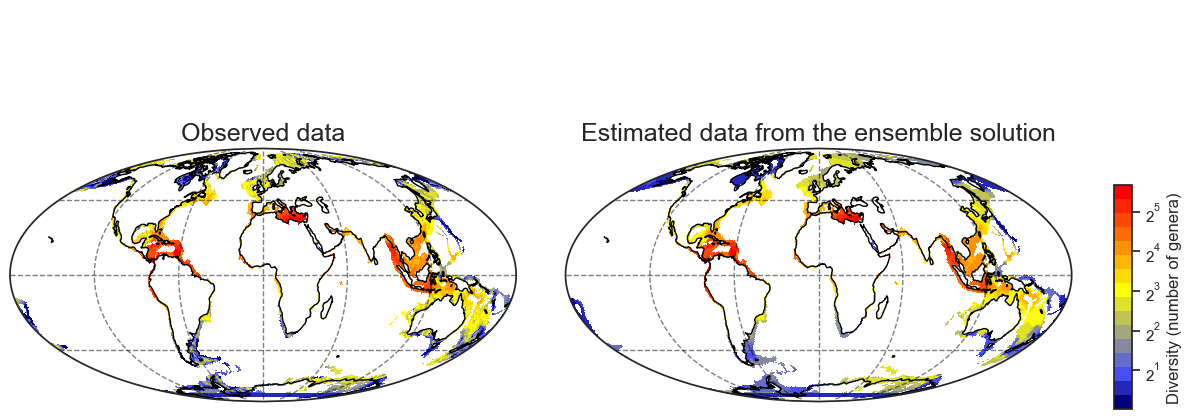

In [18]:
#Load the color map
colors_bYr = np.loadtxt("tool_for_images/mycolormap_bYr.dat")
bYr = ListedColormap(colors_bYr, name="mi_cmap_bYr")

#Divide the map into equal-sized grid cells
lats = np.linspace(-90, 90, 360)   # 360 rows -> resolution of 0.5°
lons = np.linspace(-180, 180, 720) # 720 columns -> resolution of 0.5°

#Create a grid cell using the latitudinal and longitudinal values
lon_grid, lat_grid = np.meshgrid(lons, lats)
[X,Y]=np.meshgrid(landShelfOcean_Lon,landShelfOcean_Lat)#

#Flatten the grid cell and the diversity matrix
x = X.flatten()
y = Y.flatten()
z_mean = D_mean.flatten()
z_proof = proof.flatten()

# Remove NaN values to avoid interpolating over active points
mask_proof = ~np.isnan(z_proof) & ~np.isinf(z_proof)
mask_mean = ~np.isnan(z_mean) & ~np.isinf(z_mean)
x_valid = x[mask_proof]
y_valid = y[mask_proof]
z_mean_v = z_mean[mask_mean]
z_proof_v = z_proof[mask_proof]

#Interpolate the diversity values from the mean parameters values over the active points
D_mean_interp = griddata(
    (x_valid, y_valid), 
    z_mean_v, 
    (X, Y), 
    method='linear'   #Use linear interpolation
)
#Interpolate the diversity values from the reference parameters values over the active points
D_interp = griddata(
    (x_valid, y_valid), 
    z_proof_v, 
    (X, Y), 
    method='linear'   #Use linear interpolation
)

#Filter to select only the values that correspond to the shelf area
D_mean_interp[LSOmask != 1] = np.nan
D_interp[LSOmask != 1] = np.nan

x = np.linspace(100, 10, 100)

#Create the figure
fig = plt.figure(figsize=(18, 16))

#Add padding or white space around the borders
ax_blank = fig.add_axes([0.3, 0.9, 0.5, 0.05])  # [left, bottom, width, height]
ax_blank.axis('off')

gs = GridSpec(4, 13, figure=fig, height_ratios=[2,2.5,2,1.5], width_ratios=[1]*13, hspace=0, wspace=0.8)  # 4 filas, 4 columnas de referencia

#Select the minimum and maximum values to use them as reference
vmin = min(np.nanmin(D_interp), np.nanmin(D_mean_interp))
vmax = max(np.nanmax(D_interp), np.nanmax(D_mean_interp))

#Create the first diversity map from reference values of the parameters
ax1 = fig.add_subplot(gs[0, 1:6], projection=ccrs.Mollweide())
#Plot the map
scatter1=ax1.pcolormesh(lon_grid, lat_grid,
                     D_interp, cmap=bYr, 
                     norm=LogNorm(vmin=vmin, vmax=vmax),
                       transform=ccrs.PlateCarree(), rasterized=True)
#Plot the coastlines 
ax1.coastlines()
ax1.set_global()
#Draw a grid for reference
gl1=ax1.gridlines(draw_labels=False, linestyle='--', color='black', alpha=0.5,  ylocs=[-45, 0, 45])

#Write the title
ax1.set_title('Observed data', fontsize=18)


#Create the second diversity map which corresponds to the average parameter values
ax2 = fig.add_subplot(gs[0, 6:11], projection=ccrs.Mollweide())
scatter2=ax2.pcolormesh(lon_grid, lat_grid,
                      D_mean_interp, cmap=bYr, 
                      norm=SymLogNorm(linthresh=0.001, base=2), 
                       transform=ccrs.PlateCarree(), rasterized=True)
ax2.coastlines()
ax2.set_global()

gl2=ax2.gridlines(draw_labels=False, linestyle='--', color='black', alpha=0.5,  ylocs=[-45, 0, 45])

ax2.set_title('Estimated data from the ensemble solution', fontsize=18)

cbar_ax = fig.add_axes([0.8, 0.7, 0.01, 0.14])
cbar = fig.colorbar(scatter2, ax=[ax1, ax2], cax=cbar_ax)

cbar.set_label('Diversity (number of genera)')

#Save the figure to a file and display it on screen
plt.savefig("images/map_observed_proof.svg", dpi=300)
plt.show()

## **Figure Generation: Diversity maps with disabled mechanisms**


This section generates the diversity maps from **Figure S5** of the manuscript. It consists on four panels: the first represents the biodiversity map simulated during the Proof-of-Concept, it is as a reference during the comparisons. 

The second panel shows the estimated diversity map obtained during Experiment 2 (Exponential), it is calculated with the reference values.

The third panel displays the estimated diversity map obtained during Experiment 3 (Food), it is calculated with the reference values.

The fourth panel shows the estimated diversity map obtained during Experiment 3 (Food), it is calculated with the reference values.

#### **Plot details for both maps**

- **Spatial scale and Resolution:** All the panels render global diversity maps mapping the geographic distribution of species richness.
- **Color Scale:** The diversity in the maps is represented following a $log_2$ scale to highlight variations across regions with high and low species diversity.
- **Outputs:** The figure is automatically saved in the root directory `images/map_mechanisms.png`

In [19]:
#Proof of concept
data=np.load("output_data/D_proof.npz")
D_proof=data["D"]
#No food experiment
data=np.load("output_data/D_initfood.npz")
D_initfood=data["D"]
#Exponential experiment
data=np.load("output_data/D_initexpo.npz")
D_initexpo=data["D"]
#Temperature experiment
data=np.load("output_data/D_inittemp.npz")
D_inittemp=data["D"]

In [20]:
#Load the grid that covers the Earth's surface with longitudinal and latitudinal data, which also includes
#the saved diversity values to filter the active points
data_X_Y=np.load("tool_for_images/data_X_Y.npz")
X=data_X_Y["X"]
Y=data_X_Y["Y"]
D=data_X_Y["D"]

#Create an index to filter the active points
D_nan=D[~np.isnan(D)]
ind=np.where(np.isnan(D)==0)

/tmp/ipykernel_107915/1318284803.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar0.set_ticklabels(['1', '2', '4', '8', '16', '32', '64', '128'])
/tmp/ipykernel_107915/1318284803.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar1.set_ticklabels(['1', '2', '4', '8', '16', '32', '64', '128','256','512','1024','2048'])
/tmp/ipykernel_107915/1318284803.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar2.set_ticklabels(['1', '2', '4', '8', '16', '32', '64', '128'])
/tmp/ipykernel_107915/1318284803.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar3.set_ticklabels(['1', '2', '4', '8', '16', '32', '64', '128'])


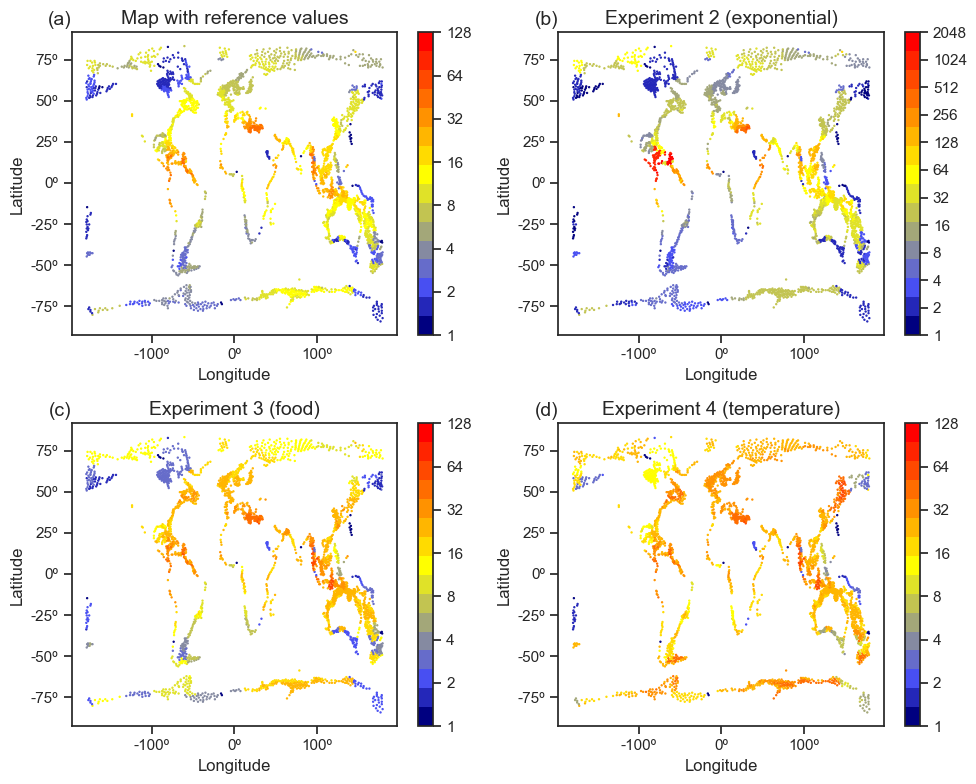

In [21]:
#Create the figure
fig, axs = plt.subplots(2, 2, figsize=(10, 8), sharex=False, sharey=False)

#Flatten the axis to simplify the plotting process
axs = axs.flatten()
#Create the proof_of_concept diversity map
ax0=axs[0]
#Plot the data using a base-2 logarithmic scale
im0=ax0.scatter(X[ind], Y[ind], c=D_proof[ind], cmap=bYr, s=0.5, norm=SymLogNorm(linthresh=0.001, base=2, vmin=1, vmax=128))

#Set the title and the horizontal and vertical axis labels
ax0.set_title("Map with reference values", fontsize=14)
ax0.set_xlabel("Longitude")
ax0.set_ylabel("Latitude")

#Create the ticks with the correct label
cbar0=plt.colorbar(im0, ax=ax0)
cbar0.set_ticklabels(['1', '2', '4', '8', '16', '32', '64', '128'])

#Do the same thing as before but for the exponential diversity map
ax1=axs[1]
im1=ax1.scatter(X[ind], Y[ind], c=D_initexpo[ind], cmap=bYr, s=0.5, norm=SymLogNorm(linthresh=0.001, base=2, vmin=1, vmax=2**11))
ax1.set_title("Experiment 2 (exponential)", fontsize=14)
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
cbar1=plt.colorbar(im1, ax=ax1)
cbar.set_ticks(2**np.arange(0,12))
cbar1.set_ticklabels(['1', '2', '4', '8', '16', '32', '64', '128','256','512','1024','2048'])

#Do the same thing as before but for the food diversity map
ax2=axs[2]
im2=ax2.scatter(X[ind], Y[ind], c=D_initfood[ind], cmap=bYr, s=0.5, norm=SymLogNorm(linthresh=0.001, base=2, vmin=1, vmax=128))
ax2.set_title("Experiment 3 (food)", fontsize=14)
ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")
cbar2=plt.colorbar(im2, ax=ax2)
cbar2.set_ticklabels(['1', '2', '4', '8', '16', '32', '64', '128'])

#Do the same thing as before but for the temperature diversity map
ax3=axs[3]
im3=ax3.scatter(X[ind], Y[ind], c=D_inittemp[ind], cmap=bYr, s=0.5, norm=SymLogNorm(linthresh=0.001, base=2, vmin=1, vmax=128))
ax3.set_title("Experiment 4 (temperature)", fontsize=14)
ax3.set_xlabel("Longitude")
ax3.set_ylabel("Latitude")
cbar3 = plt.colorbar(im3, ax=ax3)
cbar3.set_ticklabels(['1', '2', '4', '8', '16', '32', '64', '128'])

#Create the latitudinal and longitudinal ticks
for i in range(4):
    axs[i].set_yticks([-75, -50, -25, 0, 25, 50, 75])
    axs[i].set_yticklabels(['-75º', '-50º', '-25º', '0º', '25º', '50º', '75º'])
    axs[i].set_xticks([-100,0,100])
    axs[i].set_xticklabels(['-100º', '0º', '100º'])
    
#Position the panel letters correctly on each plot 
letras = ['a', 'b', 'c', 'd']

for i in range(4):
    texto = f"({letras[i]})"
    axs[i].text(-0, 1.01, texto, transform=axs[i].transAxes, 
            fontsize=14,  va='bottom', ha='right')

#Save the figure to a file and display it on screen
plt.tight_layout()
plt.savefig('images/map_mechanisms.png')
plt.show()